# Conformalized quantile regression (CQR)

**Data:** PXR training table, descriptor `morgan_r1_count_1024`, base model aligned with benchmark **hgb** (`default_cqr_hgb_regressor`).

**Plots:** reusable functions in `uncertainty.plotting` — prediction intervals as error bars on the observed–predicted scatter, and comparison to **assay** CI width / std (pEC50, Emax, Emax vs pos ctrl).

First `load_data` import may fetch the CSV from Hugging Face Hub. The first code cell adds `src/` to `sys.path` when cwd is the repo root or `notebooks/`.

In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for _p in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if _p.is_dir():
        sys.path.insert(0, str(_p.resolve()))
        break

from rdkit import Chem

from baseline import BaselineCVConfig, default_cqr_hgb_regressor, prepare_training_data
from features_data import build_descriptor_matrix
from load_data import train
from sklearn.model_selection import KFold, train_test_split
from uncertainty import cross_validate_conformal_quantile
from uncertainty.plotting import (
    PEC50_CI_LOWER,
    PEC50_CI_UPPER,
    PEC50_STD,
    assay_ci_width,
    format_uncertainty_metrics_table,
    plot_emax_uncertainty_panel,
    plot_interval_width_comparison,
    plot_pred_vs_obs_with_intervals,
    uncertainty_comparison_metrics,
)

DESCRIPTOR = "morgan_r1_count_1024"
RANDOM_STATE = 0

## Load data (aligned rows for molecules + assay columns)

`train_f` keeps the same row order as `X` / `y` so assay CI columns match test indices.

In [13]:
cfg = BaselineCVConfig()
mols = list(train["SMILES"].apply(Chem.MolFromSmiles))
y, mols_f, mask = prepare_training_data(train, mols, y_col=cfg.y_col)
train_f = train.loc[mask].reset_index(drop=True)
X = build_descriptor_matrix(DESCRIPTOR, mols_f).astype(np.float64)
print(f"{DESCRIPTOR}: X {X.shape}, y {y.shape}, train_f {len(train_f)}")

morgan_r1_count_1024: X (4140, 1024), y (4140,), train_f 4140


## Hold-out fit (index splits so `df_test` aligns with `y_test`)

In [14]:
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=0.25, random_state=RANDOM_STATE
)
idx_fit, idx_cal = train_test_split(
    idx_train, test_size=0.2, random_state=RANDOM_STATE + 1
)

X_fit, X_cal = X[idx_fit], X[idx_cal]
y_fit, y_cal = y[idx_fit], y[idx_cal]
X_test, y_test = X[idx_test], y[idx_test]
df_test = train_f.iloc[idx_test].reset_index(drop=True)

cqr = default_cqr_hgb_regressor(cfg, alpha=0.1)
cqr.fit(X_fit, y_fit, X_cal, y_cal)

y_pred = cqr.predict(X_test)
interval = cqr.predict_interval(X_test)
lower, upper = interval[:, 0], interval[:, 1]

acl = pd.to_numeric(df_test[PEC50_CI_LOWER], errors="coerce").to_numpy()
acu = pd.to_numeric(df_test[PEC50_CI_UPPER], errors="coerce").to_numpy()
astd = pd.to_numeric(df_test[PEC50_STD], errors="coerce").to_numpy()

mw = upper - lower
aw = assay_ci_width(df_test)

rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))
cov = np.mean((y_test >= lower) & (y_test <= upper))
print(f"Hold-out RMSE (median): {rmse:.4f}")
print(f"Test coverage: {cov:.3f} (nominal ~{1 - cqr.alpha:.0%})")
print(f"Mean CQR width: {np.nanmean(mw):.4f}  |  mean assay CI width: {np.nanmean(aw):.4f}")
print("\n" + format_uncertainty_metrics_table(uncertainty_comparison_metrics(mw, aw, astd)))

Hold-out RMSE (median): 0.7439
Test coverage: 0.906 (nominal ~90%)
Mean CQR width: 2.6226  |  mean assay CI width: 0.7186

  r_model_width_vs_assay_ci_width: 0.4866
  r_model_width_vs_assay_std: 0.4872


### Scatter: error bars = CQR interval (vertical) and assay pEC50 CI (horizontal)

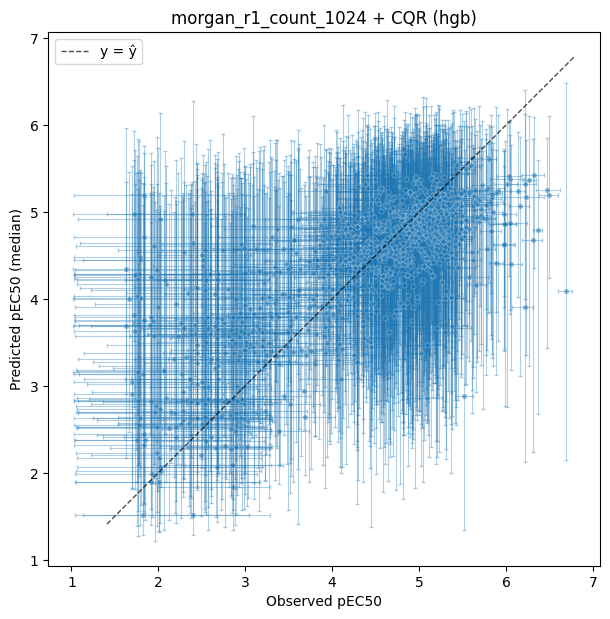

In [15]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
plot_pred_vs_obs_with_intervals(
    y_test,
    y_pred,
    lower,
    upper,
    assay_ci_lower=acl,
    assay_ci_upper=acu,
    ax=ax,
    title=f"{DESCRIPTOR} + CQR (hgb)",
)
plt.tight_layout()
plt.show()

### Width comparison: CQR vs assay CI and vs assay std error

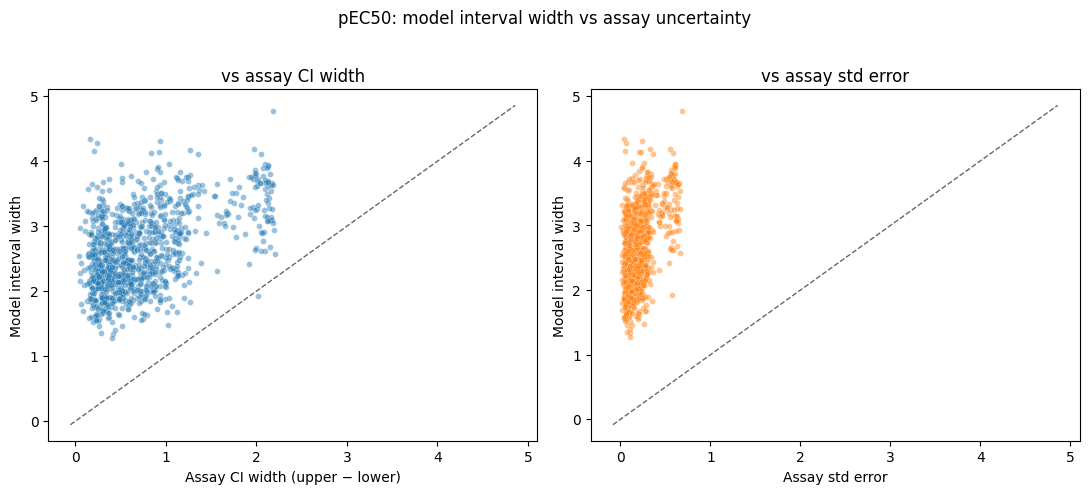

In [16]:
plot_interval_width_comparison(
    mw,
    aw,
    assay_std=astd,
    title="pEC50: model interval width vs assay uncertainty",
)
plt.tight_layout()
plt.show()

### Cross-endpoint panel: same CQR pEC50 width vs pEC50 / Emax / Emax vs pos ctrl assay CIs

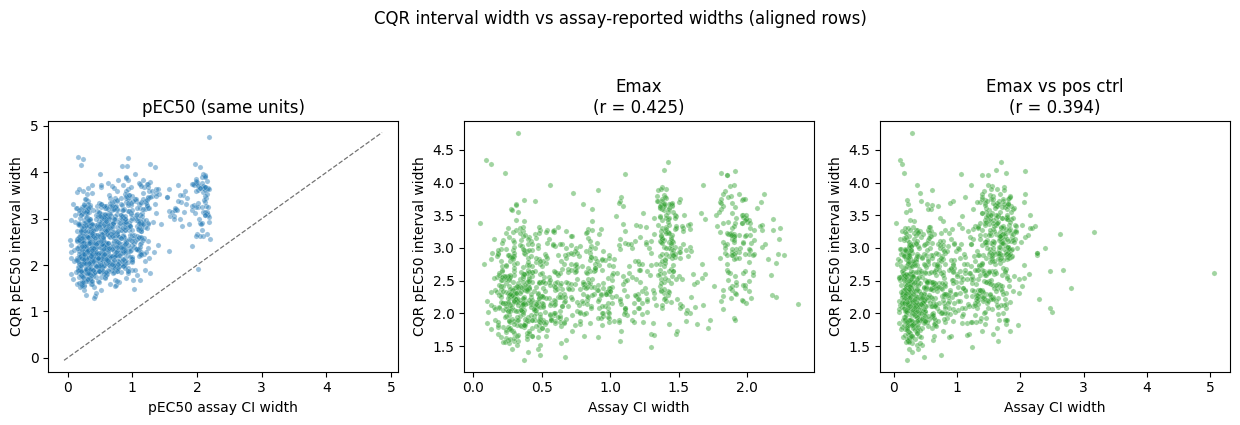

In [17]:
plot_emax_uncertainty_panel(
    df_test,
    lower,
    upper,
    suptitle="CQR interval width vs assay-reported widths (aligned rows)",
)
plt.tight_layout()
plt.show()

## Same outer `KFold` as `BaselineCVConfig` (nested calibration per fold)

In [18]:
cv = KFold(
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
    random_state=cfg.cv_random_state,
)
cqr_cv = default_cqr_hgb_regressor(cfg, alpha=0.1)

out = cross_validate_conformal_quantile(
    cqr_cv,
    X,
    y,
    cv,
    calibration_fraction=0.2,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
print("Per-fold RMSE:", np.round(out["test_rmse"], 4))
print(
    f"Mean RMSE: {out['test_rmse'].mean():.4f} ± {out['test_rmse'].std():.4f}"
)
print(f"Mean R²:   {out['test_r2'].mean():.4f}")

Per-fold RMSE: [0.733  0.7655 0.7636 0.7781 0.7762]
Mean RMSE: 0.7633 ± 0.0162
Mean R²:   0.5358


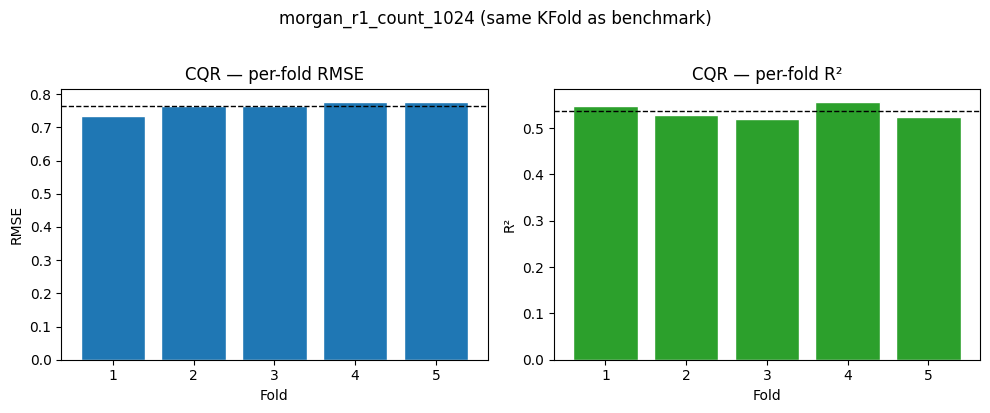

In [19]:
folds = np.arange(1, len(out["test_rmse"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(folds, out["test_rmse"], color="C0", edgecolor="white")
axes[0].axhline(out["test_rmse"].mean(), color="k", ls="--", lw=1)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("RMSE")
axes[0].set_title("CQR — per-fold RMSE")
axes[1].bar(folds, out["test_r2"], color="C2", edgecolor="white")
axes[1].axhline(out["test_r2"].mean(), color="k", ls="--", lw=1)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R²")
axes[1].set_title("CQR — per-fold R²")
fig.suptitle(f"{DESCRIPTOR} (same KFold as benchmark)", y=1.02)
plt.tight_layout()
plt.show()

## CLI: full descriptor grid

```bash
cd openadnet && PYTHONPATH=src python src/score_data_cqr.py
```